tensor(0.8277, grad_fn=<MulBackward0>)

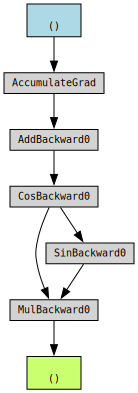

In [16]:
import torchmetrics
from IPython.display import display
from torchviz import make_dot
import torch

torch.autograd.set_detect_anomaly(True)
u = torch.tensor(2.0, requires_grad=True)
v = u + 1

w = v.cos_() * v.sin()
display(w)
dot = make_dot(w)
dot.render('/Users/johnchristensen/Library/Mobile Documents/27N4MQEA55~pro~writer/Documents/Magazine and Newspaper Notes/hands-on-machine-learning-images/cos_sin_v_graph', format='png')
display(dot)

w.backward()

tensor(-0.1397, grad_fn=<MulBackward0>)

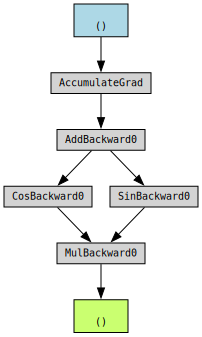

/Users/johnchristensen/hands-on-machine-learning/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:865: UserWarning: Error detected in CosBackward0. Traceback of forward call that caused the error:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/johnchristensen/hands-on-machine-learning/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/johnchristensen/hands-on-machine-learning/.venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/johnchristensen/hands-on-machine-learning/.venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/Users/johnchristensen/hands-on-machine-learning/.venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/Li

RuntimeError: one of the variables needed for gradient computation has been modified by an inplace operation: [torch.FloatTensor []], which is output 0 of SinBackward0, is at version 1; expected version 0 instead. Hint: the backtrace further above shows the operation that failed to compute its gradient. The variable in question was changed in there or anywhere later. Good luck!

In [17]:
from IPython.display import display
from torchviz import make_dot
import torch
torch.autograd.set_detect_anomaly(True)
u = torch.tensor(2.0, requires_grad=True)
v = u + 1

w = v.cos() * v.sin_()
display(w)
dot = make_dot(w)
dot.render('/Users/johnchristensen/Library/Mobile Documents/27N4MQEA55~pro~writer/Documents/Magazine and Newspaper Notes/hands-on-machine-learning-images/cos_v_sin_v_error_graph', format='png')
display(dot)

w.backward()

# Exercise 13

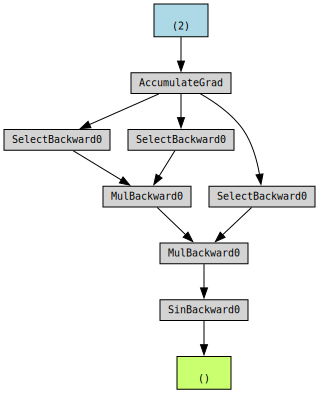

tensor([1.4899, 0.2629])

In [6]:
from IPython.display import display
from torchviz import make_dot
import torch

u = torch.tensor([1.2, 3.4],  requires_grad=True)
v = u[0] * u[0] * u[1]
w = v.sin()

dot = make_dot(w)
dot.render('/Users/johnchristensen/Library/Mobile Documents/27N4MQEA55~pro~writer/Documents/Magazine and Newspaper Notes/hands-on-machine-learning-images/cos_v_sin_v_error_graph', format='png')
display(dot)

w.backward()
u.grad

# Exercise 14

In [8]:
import torch.nn as nn

class Dense(nn.Module):
    def __init__(self, n_input, n_outputs):
        super().__init__()
        self.linear = nn.Linear(n_input, n_outputs)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.linear(x))

torch.manual_seed(42)
dense = Dense(3, 5)
X = torch.randn(2, 3)
y_pred = dense(X)
display(y_pred.shape)

y_pred_check = dense.relu(X @ dense.linear.weight.T + dense.linear.bias)
torch.allclose(y_pred, y_pred_check)


torch.Size([2, 5])

True

In [9]:
import torch.nn.functional as F

class Dense2(nn.Module):
    def __init__(self, n_input, n_outputs):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(n_outputs, n_input))
        self.bias = nn.Parameter(torch.randn(n_outputs))

    def forward(self, x):
        z = x @ self.weight.T + self.bias
        return F.relu(z)

torch.manual_seed(42)
dense2 = Dense2(3, 5)
X = torch.randn(2, 3)
y_pred2 = dense2(X)
y_pred2.shape

torch.Size([2, 5])

In [10]:
y_pred2_check = F.relu(X @ dense2.weight.T + dense2.bias)
torch.allclose(y_pred2, y_pred2_check)

True

# Exercise 15

In [24]:
from sklearn.datasets import fetch_covtype
from torch.utils.data import TensorDataset

covtype = fetch_covtype()

X_covtype = torch.tensor(covtype.data, dtype=torch.float32)
means = X_covtype.mean(dim=0, keepdim=True)
stds = X_covtype.std(dim=0, keepdim=True)

X_standardized_covtype = (X_covtype - means) / stds

y_covtype = torch.tensor(covtype.target - 1, dtype=torch.long)

covtype_dataset = TensorDataset(X_standardized_covtype, y_covtype)

sample0, target0 = covtype_dataset[0]
sample0.shape, target0.shape

(torch.Size([54]), torch.Size([]))

In [25]:
from torch.utils.data import random_split

torch.manual_seed(42)

train_size = len(covtype_dataset) * 80 // 100
valid_size = len(covtype_dataset) * 10 // 100
test_size = len(covtype_dataset) - train_size - valid_size

train_dataset, valid_dataset, test_dataset = random_split(
    covtype_dataset,
    [train_size, valid_size, test_size])

In [26]:
from torch.utils.data import DataLoader

batch_size = 256

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [31]:
import torchmetrics

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()  # reset the metric at the beginning
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)  # update it at each iteration
    return metric.compute()  # compute the final result at the end

def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
               n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

class Dense3(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, nonlinearity="relu")
        self.bias = nn.Parameter(torch.zeros(out_features))

    def forward(self, X):
        z = X @ self.weight.T + self.bias
        return F.relu(z)

class CoverTypeModel(nn.Module):
    def __init__(self, n_neurons, n_inputs=n_inputs, n_classes=n_classes):
        super().__init__()
        layers = [
            Dense3(n_in, n_out)
            for n_in, n_out in zip([n_inputs] + n_neurons, n_neurons)
        ] + [nn.Linear(n_neurons[-1], n_classes)]
        self.layers = nn.ModuleList(layers)

    def forward(self, X):
        for layer in self.layers:
            X = layer(X)
        return X

torch.manual_seed(42)
covtype_model = CoverTypeModel([200, 100, 50]).to(device)

for learning_rate in [0.16, 0.08, 0.04, 0.02, 0.01, 0.005]:
    n_epochs = 15
    optimizer = torch.optim.SGD(covtype_model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()
    metric = torchmetrics.Accuracy(task="multiclass",
                                   num_classes=n_classes).to(device)
    history = train2(covtype_model, optimizer, criterion, metric, train_loader,
                     valid_loader, n_epochs)

Epoch 1/15, train loss: 0.5830, train metric: 0.7497, valid metric: 0.7920
Epoch 2/15, train loss: 0.4600, train metric: 0.8043, valid metric: 0.8187
Epoch 3/15, train loss: 0.4095, train metric: 0.8273, valid metric: 0.8385
Epoch 4/15, train loss: 0.3705, train metric: 0.8447, valid metric: 0.8368
Epoch 5/15, train loss: 0.3450, train metric: 0.8568, valid metric: 0.8628
Epoch 6/15, train loss: 0.3244, train metric: 0.8663, valid metric: 0.8671
Epoch 7/15, train loss: 0.3086, train metric: 0.8739, valid metric: 0.8718
Epoch 8/15, train loss: 0.2946, train metric: 0.8799, valid metric: 0.8828
Epoch 9/15, train loss: 0.2832, train metric: 0.8842, valid metric: 0.8799
Epoch 10/15, train loss: 0.2735, train metric: 0.8887, valid metric: 0.8732
Epoch 11/15, train loss: 0.2651, train metric: 0.8925, valid metric: 0.8912
Epoch 12/15, train loss: 0.2574, train metric: 0.8953, valid metric: 0.8804
Epoch 13/15, train loss: 0.2513, train metric: 0.8979, valid metric: 0.8966
Epoch 14/15, train lo